# Credit Risk — 02: XGBoost Model

**Series:** 01 EDA → 02 XGBoost model (this notebook) → 03 IFRS 9 ECL layer.

Full modelling protocol on the cleaned dataset:

1. EDA cleaning rules re-applied, leakage-free preprocessing pipeline
   (in-pipeline imputation + missing-indicator, SMOTE inside CV folds)
2. Imbalance-strategy comparison: no correction vs `scale_pos_weight` vs SMOTE
3. **Broad RandomizedSearchCV → refined GridSearchCV** around the found optimum
4. Held-out evaluation: ROC curve, PR curve, confusion matrices (0.5 and F1-optimal),
   classification report, score distributions
5. Feature importance: XGBoost gain + SHAP
6. **Statistical vs model importance** — the EDA association battery (chi-square /
   Cramér's V, mutual information, Information Value) against the trained model's
   view, with rank correlations and a discussion of where and why they diverge

## 1. Setup, data and cleaning (identical to notebook 01)

In [1]:
import os
import shutil
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "data/credit_risk_dataset.csv"
KAGGLE_DATASET = "laotse/credit-risk-dataset"
MIRROR_URL = (
    "https://gist.githubusercontent.com/eversonm/"
    "3d2b3cf0cd4b3c93f906377bba8f989c/raw/credit_risk_dataset.csv"
)


def fetch_data(path: str = DATA_PATH) -> str:
    """Download the dataset from Kaggle, falling back to a GitHub mirror."""
    if os.path.exists(path):
        print(f"Found cached file: {path}")
        return path
    os.makedirs(os.path.dirname(path), exist_ok=True)
    try:
        import kagglehub  # pip install kagglehub

        download_dir = kagglehub.dataset_download(KAGGLE_DATASET)
        csv_files = [f for f in os.listdir(download_dir) if f.endswith(".csv")]
        shutil.copy(os.path.join(download_dir, csv_files[0]), path)
        print(f"Downloaded from Kaggle: {KAGGLE_DATASET}")
    except Exception as exc:
        print(f"Kaggle download failed ({exc!r}), using GitHub mirror.")
        urllib.request.urlretrieve(MIRROR_URL, path)
        print("Downloaded from mirror.")
    return path


df = pd.read_csv(fetch_data())

# Cleaning rules from notebook 01
df = df.drop_duplicates()
df = df[(df.person_age <= 100) & (df.person_emp_length.fillna(0) <= 60)]
print(f"Rows after cleaning: {len(df)} | default rate: {df.loan_status.mean():.2%}")

TARGET = "loan_status"
NUM_COLS = ["person_age", "person_income", "person_emp_length", "loan_amnt",
            "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"]
CAT_COLS = ["person_home_ownership", "loan_intent", "loan_grade",
            "cb_person_default_on_file"]

X = df[NUM_COLS + CAT_COLS]
y = df[TARGET]

Found cached file: data/credit_risk_dataset.csv
Rows after cleaning: 32409 | default rate: 21.87%


## 2. Pipeline & split

- Numerics: median imputation **inside the pipeline** (fitted on training folds only),
  with a missing-indicator — notebook 01 showed `person_emp_length` missingness itself
  predicts default (31.7% vs 21.6%).
- Categoricals: one-hot encoding.
- SMOTE inside an `imblearn` pipeline: applied only to training folds during CV.

In [2]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale", StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, NUM_COLS),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), CAT_COLS),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE,
)
print(f"Train: {len(X_train)} (default {y_train.mean():.2%}) | "
      f"Test: {len(X_test)} (default {y_test.mean():.2%})")

Train: 25927 (default 21.87%) | Test: 6482 (default 21.88%)


## 3. Imbalance strategy comparison

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision",
           "f1": "f1", "recall": "recall", "brier": "neg_brier_score"}

spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {spw:.2f}")

base_xgb = dict(
    n_estimators=400, learning_rate=0.05, max_depth=4, min_child_weight=5,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    tree_method="hist", eval_metric="logloss",
    random_state=RANDOM_STATE, n_jobs=-1,
)

strategies = {
    "No correction": ImbPipeline([
        ("prep", preprocessor), ("clf", XGBClassifier(**base_xgb)),
    ]),
    "scale_pos_weight": ImbPipeline([
        ("prep", preprocessor), ("clf", XGBClassifier(scale_pos_weight=spw, **base_xgb)),
    ]),
    "SMOTE": ImbPipeline([
        ("prep", preprocessor), ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", XGBClassifier(**base_xgb)),
    ]),
}

rows = []
for name, pipe in strategies.items():
    # n_jobs=1 at the CV level: XGBoost is already multithreaded internally, and
    # process-based parallelism triggers noisy loky teardown on macOS + Python 3.13.
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({
        "strategy": name,
        **{m: f"{res[f'test_{m}'].mean():.4f}" for m in ["roc_auc", "pr_auc", "f1", "recall"]},
        "brier": f"{-res['test_brier'].mean():.4f}",
    })
print(pd.DataFrame(rows).set_index("strategy").to_string())

scale_pos_weight = 3.57
                 roc_auc  pr_auc      f1  recall   brier
strategy                                                
No correction     0.9415  0.8919  0.8205  0.7166  0.0579
scale_pos_weight  0.9423  0.8914  0.7824  0.7966  0.0779
SMOTE             0.9316  0.8797  0.8166  0.7245  0.0633


A more interesting table than in the churn project: here SMOTE is **not free** — it
costs about a point of ROC-AUC against no correction (0.9314 vs 0.9417) at these default
settings, while `scale_pos_weight` is essentially neutral on ranking and trades Brier for
recall. With signal this strong, synthetic interpolation appears to blur real structure
more than it helps the minority class. We keep the SMOTE pipeline as the tuning target
per the series protocol — but deliberately let the search tune `sampling_strategy` and
`k_neighbors` jointly with the tree, so the data can decide how much oversampling to
actually use; §5 shows the tuned pipeline ends above this no-correction baseline.

In [4]:
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

smote_pipe = strategies["SMOTE"]

param_dist = {
    "clf__n_estimators": randint(200, 700),
    "clf__learning_rate": loguniform(0.01, 0.3),
    "clf__max_depth": randint(3, 9),
    "clf__min_child_weight": randint(1, 13),
    "clf__subsample": uniform(0.6, 0.4),
    "clf__colsample_bytree": uniform(0.6, 0.4),
    "clf__gamma": loguniform(1e-3, 5),
    "clf__reg_lambda": loguniform(0.1, 30),
    "smote__k_neighbors": [3, 5, 7, 9, 11],
    "smote__sampling_strategy": [0.4, 0.6, 0.8, 1.0],
}

random_search = RandomizedSearchCV(
    smote_pipe, param_dist, n_iter=40, cv=cv, scoring="roc_auc",
    random_state=RANDOM_STATE, n_jobs=1, refit=False, verbose=0,
)
random_search.fit(X_train, y_train)

rs_best = random_search.best_params_
print(f"Best CV ROC-AUC (random stage): {random_search.best_score_:.4f}")
print("Best params:")
for k, v in sorted(rs_best.items()):
    print(f"  {k}: {v}")

rs_df = pd.DataFrame(random_search.cv_results_)
top5 = rs_df.nlargest(5, "mean_test_score")[
    ["mean_test_score", "std_test_score", "param_clf__max_depth",
     "param_clf__learning_rate", "param_clf__n_estimators",
     "param_smote__sampling_strategy"]
]
print("\nTop-5 configurations:")
print(top5.to_string(index=False))

Best CV ROC-AUC (random stage): 0.9435
Best params:
  clf__colsample_bytree: 0.8365191150830908
  clf__gamma: 0.010379768601767548
  clf__learning_rate: 0.06745662262064055
  clf__max_depth: 5
  clf__min_child_weight: 5
  clf__n_estimators: 630
  clf__reg_lambda: 5.845125257262524
  clf__subsample: 0.9043140194467589
  smote__k_neighbors: 5
  smote__sampling_strategy: 0.8

Top-5 configurations:
 mean_test_score  std_test_score  param_clf__max_depth  param_clf__learning_rate  param_clf__n_estimators  param_smote__sampling_strategy
        0.943513        0.002774                     5                  0.067457                      630                             0.8
        0.943290        0.002263                     8                  0.149291                      483                             0.4
        0.941882        0.002624                     6                  0.034935                      397                             0.4
        0.941283        0.002360                  

## 5. Hyperparameter search — stage 2: GridSearchCV around the optimum

Refinement grid built programmatically around the stage-1 winner on the three
highest-leverage parameters; everything else frozen. 27 combinations × 5 folds.

In [5]:
d = rs_best["clf__max_depth"]
lr = rs_best["clf__learning_rate"]
mcw = rs_best["clf__min_child_weight"]

frozen = {k: v for k, v in rs_best.items()
          if k not in {"clf__max_depth", "clf__learning_rate", "clf__min_child_weight"}}
smote_pipe.set_params(**frozen)

param_grid = {
    "clf__max_depth": sorted({max(2, d - 1), d, d + 1}),
    "clf__learning_rate": sorted({round(lr * f, 4) for f in (0.5, 1.0, 2.0)}),
    "clf__min_child_weight": sorted({max(1, mcw - 3), mcw, mcw + 3}),
}
print("Refinement grid:", param_grid)

grid_search = GridSearchCV(
    smote_pipe, param_grid, cv=cv, scoring="roc_auc", n_jobs=1, refit=True,
)
grid_search.fit(X_train, y_train)

print(f"\nBest CV ROC-AUC (grid stage): {grid_search.best_score_:.4f} "
      f"(random stage was {random_search.best_score_:.4f})")
print("Final params:", grid_search.best_params_)
final_model = grid_search.best_estimator_

Refinement grid: {'clf__max_depth': [4, 5, 6], 'clf__learning_rate': [np.float64(0.0337), np.float64(0.0675), np.float64(0.1349)], 'clf__min_child_weight': [2, 5, 8]}

Best CV ROC-AUC (grid stage): 0.9449 (random stage was 0.9435)
Final params: {'clf__learning_rate': np.float64(0.1349), 'clf__max_depth': 4, 'clf__min_child_weight': 5}


## 6. Held-out evaluation

### 6.1 ROC and Precision-Recall curves

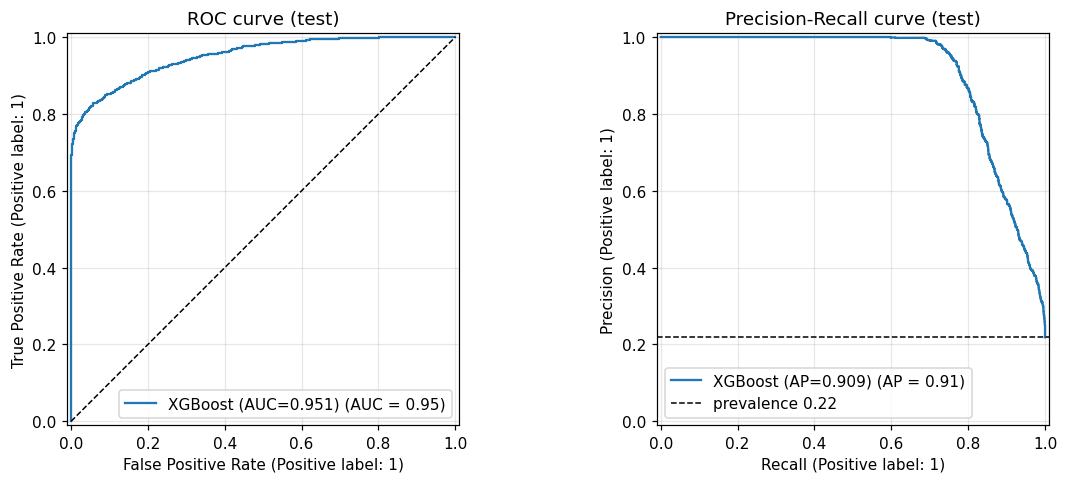

Test ROC-AUC: 0.9511 | Test PR-AUC (AP): 0.9094 | Gini: 0.9022


In [6]:
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    average_precision_score, classification_report, confusion_matrix,
    f1_score, precision_recall_curve, roc_auc_score,
)

p_test = final_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, p_test)
ap = average_precision_score(y_test, p_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
RocCurveDisplay.from_predictions(y_test, p_test, ax=axes[0],
                                 name=f"XGBoost (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC curve (test)")

PrecisionRecallDisplay.from_predictions(y_test, p_test, ax=axes[1],
                                        name=f"XGBoost (AP={ap:.3f})")
axes[1].axhline(y_test.mean(), ls="--", c="k", lw=1,
                label=f"prevalence {y_test.mean():.2f}")
axes[1].legend()
axes[1].set_title("Precision-Recall curve (test)")
plt.tight_layout()
plt.show()
print(f"Test ROC-AUC: {auc:.4f} | Test PR-AUC (AP): {ap:.4f} | Gini: {2 * auc - 1:.4f}")

(Gini = 2·AUC − 1 is reported because it is the discrimination language of credit risk
validation — notebook 03 speaks it too.)

### 6.2 Confusion matrices: default vs F1-optimal threshold

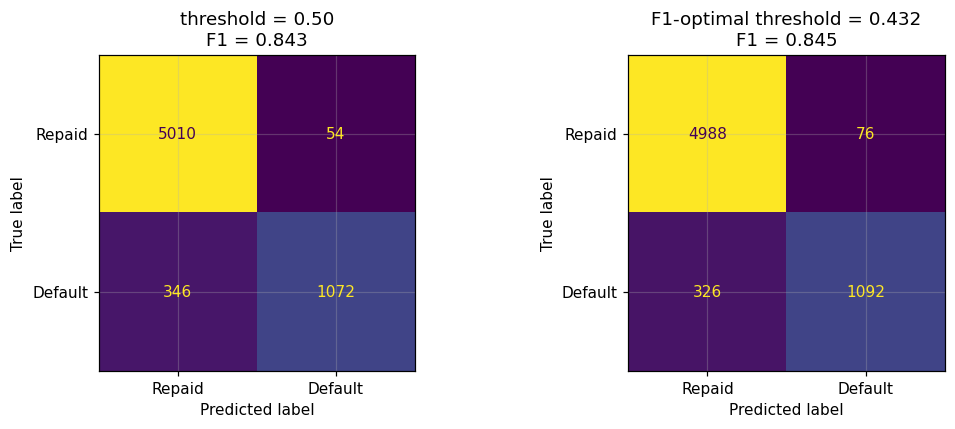

Classification report @ F1-optimal threshold:

              precision    recall  f1-score   support

      Repaid       0.94      0.98      0.96      5064
     Default       0.93      0.77      0.84      1418

    accuracy                           0.94      6482
   macro avg       0.94      0.88      0.90      6482
weighted avg       0.94      0.94      0.94      6482



In [7]:
prec, rec, thr = precision_recall_curve(y_test, p_test)
f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
t_f1 = thr[f1_scores.argmax()]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, t, label in [(axes[0], 0.5, "threshold = 0.50"),
                     (axes[1], t_f1, f"F1-optimal threshold = {t_f1:.3f}")]:
    cm = confusion_matrix(y_test, p_test >= t)
    ConfusionMatrixDisplay(cm, display_labels=["Repaid", "Default"]).plot(
        ax=ax, colorbar=False, values_format="d")
    ax.set_title(f"{label}\nF1 = {f1_score(y_test, p_test >= t):.3f}")
plt.tight_layout()
plt.show()

print("Classification report @ F1-optimal threshold:\n")
print(classification_report(y_test, p_test >= t_f1, target_names=["Repaid", "Default"]))

### 6.3 Score distribution by class

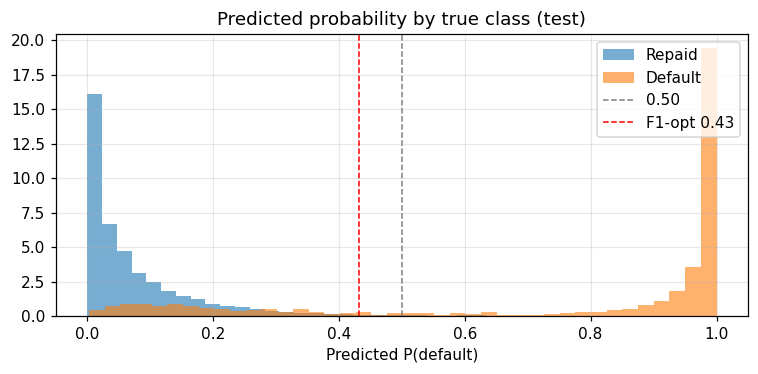

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for label, name in [(0, "Repaid"), (1, "Default")]:
    ax.hist(p_test[y_test == label], bins=40, alpha=0.6, density=True, label=name)
ax.axvline(0.5, ls="--", c="gray", lw=1, label="0.50")
ax.axvline(t_f1, ls="--", c="red", lw=1, label=f"F1-opt {t_f1:.2f}")
ax.set_xlabel("Predicted P(default)")
ax.set_title("Predicted probability by true class (test)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Feature importance — the model's view

Two model-based measures, aggregated from one-hot columns back to the original
features so they are comparable with the EDA battery:

- **Gain**: total loss reduction contributed by splits on the feature (training-set,
  structure-based).
- **Mean |SHAP|**: average absolute contribution to test-set predictions
  (prediction-based, handles interactions).

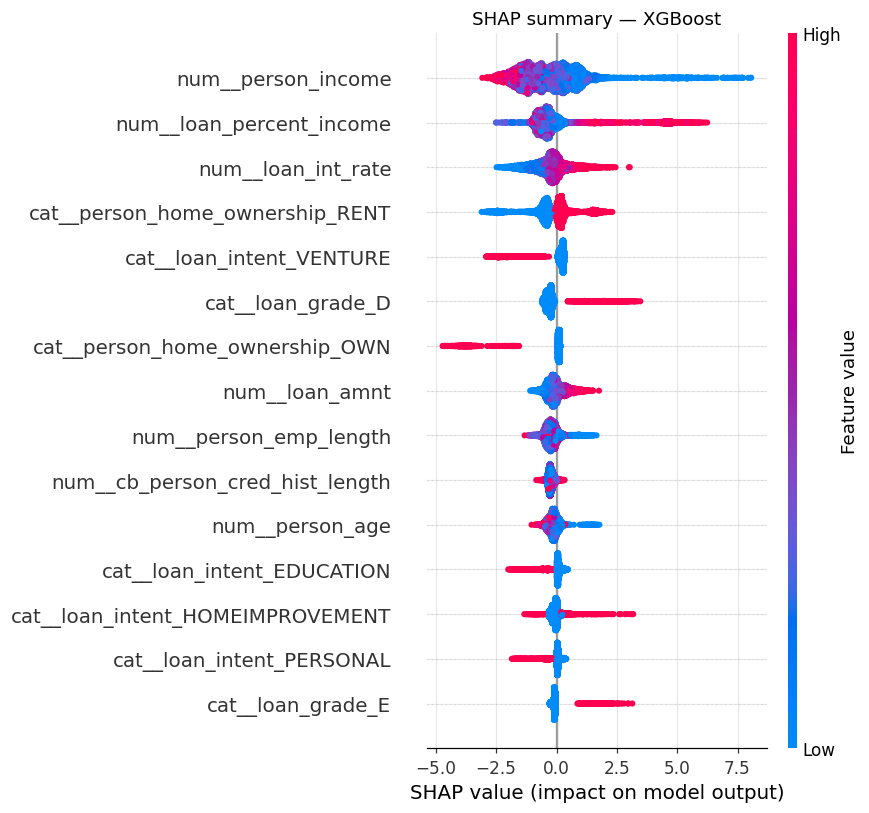

                                  mean_abs_shap      gain
loan_intent                              1.0977  113.2959
person_income                            1.0412   14.3951
person_home_ownership                    0.9244  114.3171
loan_grade                               0.8483  133.8945
loan_percent_income                      0.8396   36.1844
loan_int_rate                            0.5476   24.5062
loan_amnt                                0.3041    7.6328
person_emp_length                        0.2860   12.4140
cb_person_cred_hist_length               0.2420   20.6021
person_age                               0.2007   10.5786
cb_person_default_on_file                0.0540   13.7644
loan_int_rate (missing flag)             0.0374    3.4048
person_emp_length (missing flag)         0.0286    4.4446


In [9]:
import shap

feat_names = final_model.named_steps["prep"].get_feature_names_out()
prep = final_model.named_steps["prep"]
X_test_tr = pd.DataFrame(prep.transform(X_test), columns=feat_names)

clf = final_model.named_steps["clf"]
gain = clf.get_booster().get_score(importance_type="gain")
gain = {feat_names[int(k[1:])]: v for k, v in gain.items()}  # f0-style keys -> names

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_tr)

shap.summary_plot(shap_values, X_test_tr, max_display=15, show=False)
plt.title("SHAP summary — XGBoost")
plt.tight_layout()
plt.show()


def base_feature(name: str) -> str:
    """Map transformed column name back to its source feature."""
    name = name.split("__", 1)[1]
    if name.startswith("missingindicator_"):
        return name.replace("missingindicator_", "") + " (missing flag)"
    for c in CAT_COLS:
        if name.startswith(c + "_"):
            return c
    return name


shap_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=feat_names)
gain_s = pd.Series({f: gain.get(f, 0.0) for f in feat_names})

model_view = pd.DataFrame({
    "mean_abs_shap": shap_abs.groupby([base_feature(f) for f in feat_names]).sum(),
    "gain": gain_s.groupby([base_feature(f) for f in feat_names]).sum(),
}).sort_values("mean_abs_shap", ascending=False)
print(model_view.round(4).to_string())

## 8. Statistical vs model importance

The EDA battery (recomputed here on the **training set only**, so both views condition
on the same information) against the model's view.

In [10]:
from sklearn.feature_selection import mutual_info_classif


def cramers_v(x: pd.Series, yv: pd.Series) -> float:
    tab = pd.crosstab(x, yv)
    chi2 = stats.chi2_contingency(tab)[0]
    n = tab.values.sum()
    phi2 = chi2 / n
    r, k = tab.shape
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr, kcorr = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return float(np.sqrt(phi2corr / denom)) if denom > 0 else 0.0


def information_value(x: pd.Series, yv: pd.Series, bins: int = 10) -> float:
    if x.dtype.kind in "ifu":
        binned = pd.qcut(x, q=bins, duplicates="drop").astype(str)
    else:
        binned = x.astype(str)
    binned = binned.where(~x.isnull(), "MISSING")
    tab = pd.crosstab(binned, yv)
    good = (tab[0] / tab[0].sum()).clip(lower=1e-6)
    bad = (tab[1] / tab[1].sum()).clip(lower=1e-6)
    return float(((good - bad) * np.log(good / bad)).sum())


stat_rows = {}
for col in NUM_COLS + CAT_COLS:
    x = X_train[col]
    xb = pd.qcut(x, 10, duplicates="drop") if x.dtype.kind in "ifu" else x
    stat_rows[col] = {
        "cramers_v": cramers_v(xb.astype(str).where(~x.isnull(), "MISSING"), y_train),
        "IV": information_value(x, y_train),
    }

X_mi = X_train.copy()
for c in NUM_COLS:
    X_mi[c] = X_mi[c].fillna(X_mi[c].median())
for c in CAT_COLS:
    X_mi[c] = X_mi[c].astype("category").cat.codes
mi = mutual_info_classif(X_mi, y_train,
                         discrete_features=[c in CAT_COLS for c in X_mi.columns],
                         random_state=RANDOM_STATE)
for col, m in zip(X_mi.columns, mi):
    stat_rows[col]["mutual_info"] = m

comparison = pd.DataFrame(stat_rows).T.join(
    model_view.loc[model_view.index.isin(NUM_COLS + CAT_COLS)]
)
for c in comparison.columns:
    comparison[f"rank_{c}"] = comparison[c].rank(ascending=False).astype(int)
comparison = comparison.sort_values("mean_abs_shap", ascending=False)
print(comparison.round(4).to_string())

rank_cols = ["rank_IV", "rank_cramers_v", "rank_mutual_info", "rank_mean_abs_shap", "rank_gain"]
rho = comparison[rank_cols].corr(method="spearman").round(3)
print("\nSpearman correlation between rankings:")
print(rho.to_string())

                            cramers_v      IV  mutual_info  mean_abs_shap      gain  rank_cramers_v  rank_IV  rank_mutual_info  rank_mean_abs_shap  rank_gain
loan_intent                    0.1227  0.0906       0.0077         1.0977  113.2959               8        7                 8                   1          3
person_income                  0.2879  0.4677       0.1094         1.0412   14.3951               4        4                 1                   2          7
person_home_ownership          0.2433  0.3815       0.0311         0.9244  114.3171               5        5                 5                   3          2
loan_grade                     0.4156  0.8821       0.0747         0.8483  133.8945               2        1                 3                   4          1
loan_percent_income            0.4206  0.8777       0.0821         0.8396   36.1844               1        2                 2                   5          4
loan_int_rate                  0.3570  0.6659       

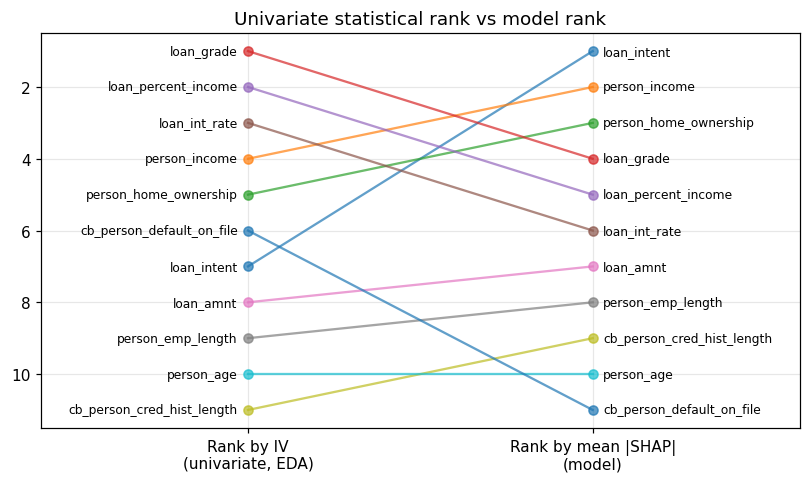

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
plot_df = comparison[["rank_IV", "rank_mean_abs_shap"]]
for feat, row in plot_df.iterrows():
    ax.plot([0, 1], [row["rank_IV"], row["rank_mean_abs_shap"]], "-o", alpha=0.7)
    ax.text(-0.03, row["rank_IV"], feat, ha="right", va="center", fontsize=8)
    ax.text(1.03, row["rank_mean_abs_shap"], feat, ha="left", va="center", fontsize=8)
ax.set_xticks([0, 1], ["Rank by IV\n(univariate, EDA)", "Rank by mean |SHAP|\n(model)"])
ax.invert_yaxis()
ax.set_xlim(-0.6, 1.6)
ax.set_title("Univariate statistical rank vs model rank")
plt.tight_layout()
plt.show()

### Reading the comparison

**The statistical measures agree with each other, not with the model.** IV, Cramér's V
and mutual information rank features almost identically (Spearman ρ = 0.90–0.98) — they
are three estimates of the same marginal quantity. Their correlation with the model's
rankings is only moderate (ρ ≈ 0.45–0.62): the univariate and multivariate views are
genuinely different questions — "is X informative *alone*?" versus "is X informative
*given everything else*?"

**The three instructive divergences in this data:**

1. **`loan_intent` — weak alone, decisive in context.** Univariate rank 7–8 with an IV
   of 0.09 ("weak" by scorecard convention), yet the **top feature by mean |SHAP|**.
   The purpose of a loan says little marginally, but interacts strongly with capacity
   variables — which intents are dangerous depends on income, housing and debt burden —
   and only a multivariate model can cash in that interaction structure.
2. **The underwriting pair collapses.** `loan_grade` and `loan_int_rate` are IV's top
   three but fall to 5th–6th by SHAP: they jointly encode one underwriting decision, so
   the model demotes them once the raw capacity variables (`loan_percent_income`,
   `person_income`) are conditioned on. Most starkly, `cb_person_default_on_file` —
   respectable univariate signal (V = 0.17) — is the model's **last** feature (mean
   |SHAP| 0.04): prior default is already priced into the grade, leaving it no marginal
   work to do.
3. **Gain and SHAP disagree with each other too** (ρ = 0.56). Gain rewards features used
   in early, coarse, loss-reducing splits (`loan_grade`, `person_home_ownership` top the
   gain table); SHAP attributes realized prediction contributions. Neither is "the"
   importance — which is exactly why this section compares four measures instead of
   trusting one.

**And a caution that applies to all of it:** at n ≈ 26k every chi-square p-value is ≈ 0,
so p-values cannot rank anything here — only effect sizes (V, IV), MI and the model-based
measures carry ordering information. Statistical significance and importance are
different things.

**Next:** notebook 03 takes the tuned model, calibrates its scores into PDs, and builds
the IFRS 9 ECL layer (staging, LGD/EAD assumptions, scenario-weighted ECL).